## [1]  IOU

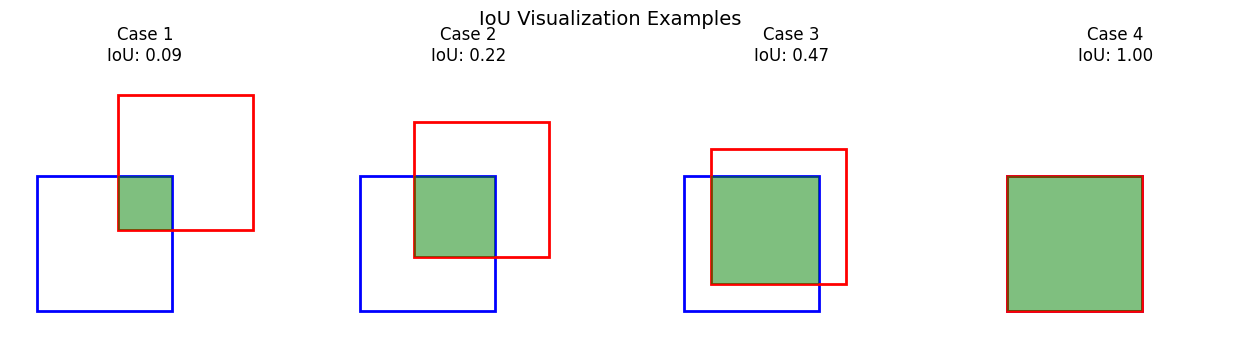

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

cases = [
    {"A": (20, 20, 120, 120), "B": (80, 80, 180, 180), "title": "Case 1"},  # IoU ~0.14
    {"A": (20, 20, 120, 120), "B": (60, 60, 160, 160), "title": "Case 2"},  # IoU ~0.47
    {"A": (20, 20, 120, 120), "B": (40, 40, 140, 140), "title": "Case 3"},  # IoU ~0.68
    {"A": (20, 20, 120, 120), "B": (20, 20, 120, 120), "title": "Case 4"},  # IoU = 1.0
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, case in enumerate(cases):
    boxA, boxB, ax = case["A"], case["B"], axes[i]

    # Intersection
    x1, y1 = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    x2, y2 = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    inter_w, inter_h = max(0, x2-x1), max(0, y2-y1)
    inter_area = inter_w * inter_h

    # Areas
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter_area
    iou = inter_area / union if union > 0 else 0

    # Box A (blue)
    ax.add_patch(patches.Rectangle((boxA[0], boxA[1]), boxA[2]-boxA[0], boxA[3]-boxA[1],
                                   edgecolor="blue", facecolor="none", linewidth=2, label="A"))
    # Box B (red)
    ax.add_patch(patches.Rectangle((boxB[0], boxB[1]), boxB[2]-boxB[0], boxB[3]-boxB[1],
                                   edgecolor="red", facecolor="none", linewidth=2, label="B"))
    # Intersection (green)
    if inter_w > 0 and inter_h > 0:
        ax.add_patch(patches.Rectangle((x1, y1), inter_w, inter_h,
                                       facecolor="green", alpha=0.5))

    ax.set_xlim(0, 200); ax.set_ylim(0, 200)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f'{case["title"]}\nIoU: {iou:.2f}')

plt.suptitle("IoU Visualization Examples", fontsize=14)
plt.show()


## [2] 욜로 객체검출

In [8]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.8 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. 모델 불러오기
model = YOLO("yolov8n.pt")  # 사전학습된 모델

# 2. 이미지 추론
results = model("test.jpg")  # 추론할 이미지

# 3. 첫 번째 결과에서 첫 번째 박스 하나만 가져오기
boxes = results[0].boxes.xyxy.cpu().numpy()   # (x1,y1,x2,y2)
scores = results[0].boxes.conf.cpu().numpy() # confidence
classes = results[0].boxes.cls.cpu().numpy() # class

boxes

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/test.jpg: 448x640 3 persons, 10 cars, 1 tie, 350.2ms
Speed: 17.8ms preprocess, 350.2ms inference, 31.5ms postprocess per image at shape (1, 3, 448, 640)


array([[     2182.1,      1513.4,        3237,        3322],
       [     3284.8,        2075,      4573.5,      2666.8],
       [     1514.6,      1619.3,      2061.8,      3182.4],
       [     4467.1,      2174.1,      4692.2,      2381.8],
       [     4618.2,      2138.1,      4894.6,      2368.3],
       [     3044.4,        2112,      3691.2,      2529.1],
       [     4867.2,      2177.9,      5052.5,      2361.1],
       [       2292,      2248.8,      2679.1,      2594.2],
       [     3033.7,      2169.3,      3303.4,      2533.2],
       [     4360.6,      2147.9,      4707.3,      2379.3],
       [     1584.9,      1929.7,      2014.6,      3188.6],
       [     2757.2,      1807.6,      2902.8,        2399],
       [     3238.5,      2113.6,      3665.2,      2363.1],
       [     4610.8,      2146.9,      4823.3,      2367.3]], dtype=float32)

In [12]:
box_pred = boxes[0]   # 첫 번째 객체만 선택 (예: [x1,y1,x2,y2])
conf = scores[0]
cls  = int(classes[0])

print("Predicted box:", box_pred, "conf:", conf, "class:", cls)
print("conf:", conf)
print("class:", cls)

Predicted box: [     2182.1      1513.4        3237        3322] conf: 0.91315967 class: 0
conf: 0.91315967
class: 0



image 1/1 /content/test.jpg: 448x640 3 persons, 10 cars, 1 tie, 169.6ms
Speed: 4.5ms preprocess, 169.6ms inference, 2.9ms postprocess per image at shape (1, 3, 448, 640)


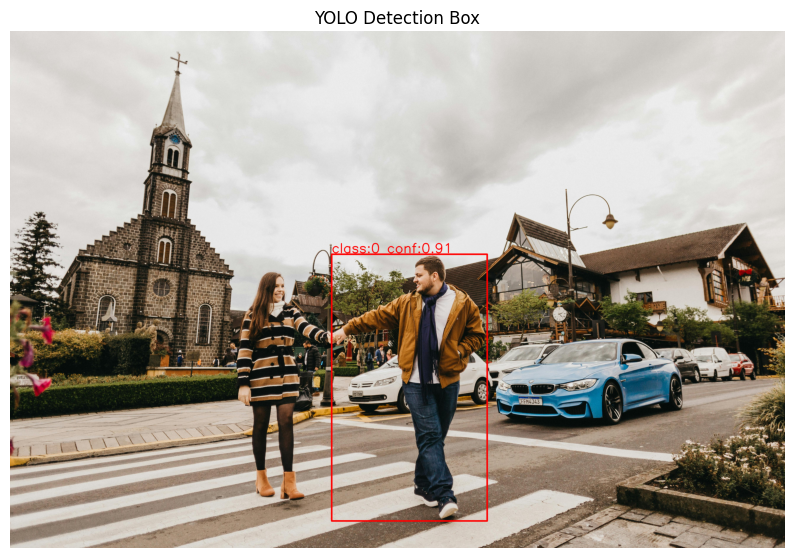

In [20]:
###################3
## Draw YOLO Detection Box with OpenCV
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. 모델 불러오기 및 추론
model = YOLO("yolov8n.pt")
results = model("test.jpg")

# 2. 박스, 점수, 클래스 추출
boxes = results[0].boxes.xyxy.cpu().numpy()   # (x1,y1,x2,y2)
scores = results[0].boxes.conf.cpu().numpy() # confidence
classes = results[0].boxes.cls.cpu().numpy() # class

# 3. 원본 이미지 불러오기
img = cv2.imread("test.jpg")

# 4. 첫 번째 박스만 예시로 사용
x1, y1, x2, y2 = map(int, boxes[0])
conf = scores[0]
cls  = int(classes[0])

# 5. OpenCV로 박스 + 텍스트 그리기
cv2.rectangle(img, (x1, y1), (x2, y2), (0,0,255), 10)  # 빨간 박스
cv2.putText(img, f"class:{cls} conf:{conf:.2f}",
            (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
            3, (0,0,255), 5)

# 6. 마지막에만 plt로 출력 (BGR → RGB 변환)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.title("YOLO Detection Box")
plt.axis("off")
plt.show()



image 1/1 /content/test.jpg: 448x640 3 persons, 10 cars, 1 tie, 165.9ms
Speed: 4.6ms preprocess, 165.9ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)


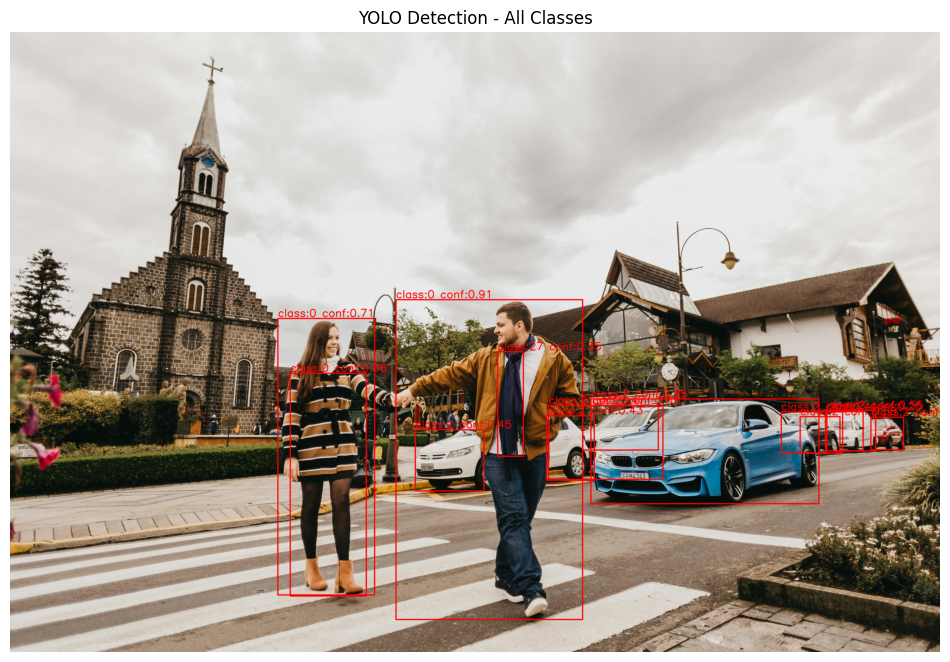

In [21]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. 모델 불러오기 및 추론
model = YOLO("yolov8n.pt")
results = model("test.jpg")

# 2. 박스, 점수, 클래스 추출
boxes = results[0].boxes.xyxy.cpu().numpy()
scores = results[0].boxes.conf.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy().astype(int)

# 3. 원본 이미지 불러오기
img = cv2.imread("test.jpg")

# 4. 모든 박스 루프
for (x1, y1, x2, y2), conf, cls in zip(boxes, scores, classes):
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    # 박스 그리기
    cv2.rectangle(img, (x1, y1), (x2, y2), (0,0,255), 5)

    # 텍스트 (크기 키움)
    cv2.putText(
        img, f"class:{cls} conf:{conf:.2f}",
        (x1, max(y1-10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        2.0, (0,0,255), 4, cv2.LINE_AA
    )

# 5. 마지막에만 plt로 출력 (BGR → RGB 변환)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,12))
plt.imshow(img_rgb)
plt.title("YOLO Detection - All Classes")
plt.axis("off")
plt.show()

## [3] IOU & 욜로


image 1/1 /content/test.jpg: 448x640 3 persons, 10 cars, 1 tie, 181.3ms
Speed: 4.5ms preprocess, 181.3ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)
IoU: 0.8788374


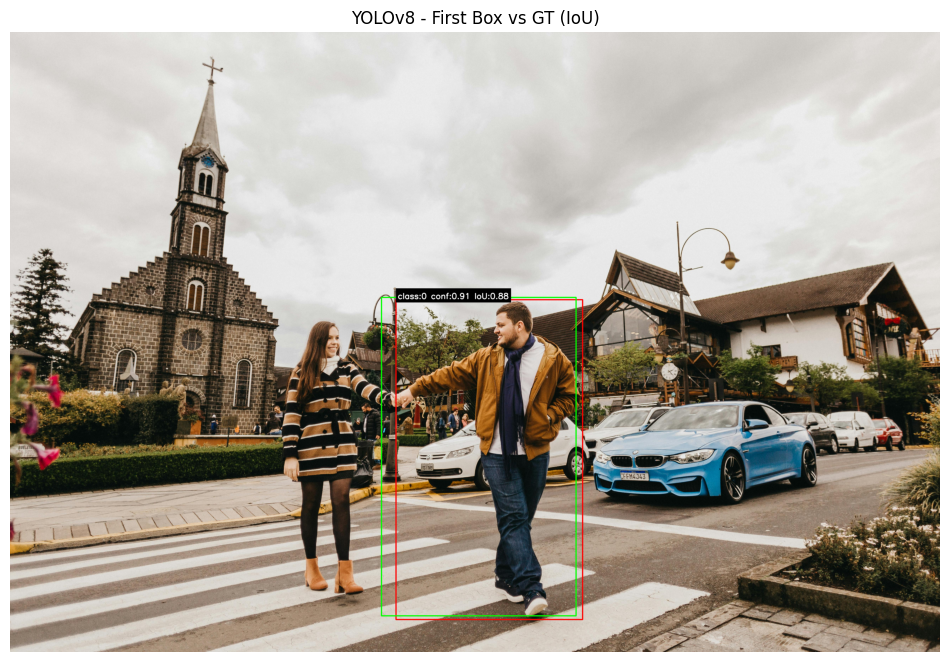

In [27]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. 모델 불러오기 및 추론
model = YOLO("yolov8n.pt")
results = model("test.jpg")

# 2. 첫 번째 박스 정보만 추출
boxes   = results[0].boxes.xyxy.cpu().numpy()
scores  = results[0].boxes.conf.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy().astype(int)

pred_box = boxes[0]  # (x1, y1, x2, y2)
conf = scores[0]
cls  = int(classes[0])

# 3. 예시 GT 박스 (실제 라벨 값으로 바꿔야 함)
gt_box = [2100, 1500, 3200, 3300]  # (x1, y1, x2, y2)

# 4. IoU 계산 함수
def calc_iou(boxA, boxB):
    x1, y1 = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    x2, y2 = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return inter / (areaA + areaB - inter + 1e-6)

iou = calc_iou(pred_box, gt_box)
print("IoU:", iou)

# 5. 원본 이미지 불러오기
img = cv2.imread("test.jpg")

# 6. 색상 정의
pred_color = (0, 0, 255)   # 예측 박스 빨강
gt_color   = (0, 255, 0)   # GT 박스 초록

# 7. 박스 그리기
px1, py1, px2, py2 = map(int, pred_box)
gx1, gy1, gx2, gy2 = map(int, gt_box)

cv2.rectangle(img, (px1, py1), (px2, py2), pred_color, 6)  # 예측
cv2.rectangle(img, (gx1, gy1), (gx2, gy2), gt_color, 6)    # GT

# 8. 텍스트 (class + conf + IoU)
label = f"class:{cls} conf:{conf:.2f} IoU:{iou:.2f}"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1.5
thickness = 3

# 텍스트 크기 계산
(text_w, text_h), baseline = cv2.getTextSize(label, font, font_scale, thickness)

# 배경 패딩 값 추가
pad_x, pad_y = 20, 15  # 좌우/상하 패딩

# 검정색 배경 (패딩 포함)
cv2.rectangle(
    img,
    (px1, py1 - text_h - baseline - pad_y),
    (px1 + text_w + pad_x, py1 + pad_y),
    (0, 0, 0), -1
)

# 텍스트 그리기 (흰색)
cv2.putText(
    img, label,
    (px1 + int(pad_x/2), py1 - 5),
    font, font_scale,
    (255, 255, 255), thickness, cv2.LINE_AA
)

# 9. 출력 (BGR → RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,12))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("YOLOv8 - First Box vs GT (IoU)")
plt.show()


In [28]:
# 주어진 좌표
#
true_box = [2100, 1500, 3200, 3300]   # (x1, y1, x2, y2)
pred_box = [2182.1, 1513.4, 3237, 3322]

# 실제 좌표
x1_true, y1_true, x2_true, y2_true = true_box
x1_pred, y1_pred, x2_pred, y2_pred = pred_box

# 교집합 좌표
xi1 = max(x1_true, x1_pred)
yi1 = max(y1_true, y1_pred)
xi2 = min(x2_true, x2_pred)
yi2 = min(y2_true, y2_pred)

# 교집합 영역 (음수 방지)
inter_width = max(0, xi2 - xi1)
inter_height = max(0, yi2 - yi1)
inter_area = inter_width * inter_height

# 각 박스 면적
area_true = (x2_true - x1_true) * (y2_true - y1_true)
area_pred = (x2_pred - x1_pred) * (y2_pred - y1_pred)

# 합집합 면적
union_area = area_true + area_pred - inter_area

# IoU 계산
iou = inter_area / union_area
iou


0.8788332257291313

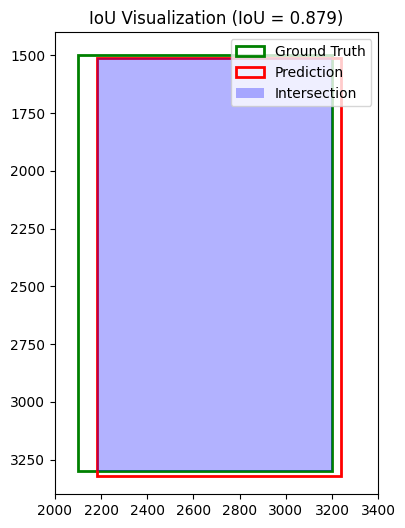

In [30]:
# 그림 생성 (영문 라벨로)
fig, ax = plt.subplots(figsize=(6,6))

# 실제 박스 (green)
rect_true = patches.Rectangle((x1_true, y1_true), x2_true - x1_true, y2_true - y1_true,
                              linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
ax.add_patch(rect_true)

# 예측 박스 (red)
rect_pred = patches.Rectangle((x1_pred, y1_pred), x2_pred - x1_pred, y2_pred - y1_pred,
                              linewidth=2, edgecolor='r', facecolor='none', label='Prediction')
ax.add_patch(rect_pred)

# 교집합 영역 (blue transparent)
if inter_area > 0:
    rect_inter = patches.Rectangle((xi1, yi1), inter_width, inter_height,
                                   linewidth=0, edgecolor='none', facecolor='blue', alpha=0.3, label='Intersection')
    ax.add_patch(rect_inter)

# 축과 범례
ax.set_xlim(2000, 3400)
ax.set_ylim(1400, 3400)
ax.set_aspect('equal', adjustable='box')
ax.legend()
plt.title(f"IoU Visualization (IoU = {iou:.3f})")
plt.gca().invert_yaxis()  # 이미지 좌표계처럼 y축 반전
plt.show()
